# NHL Salary Cap Efficiency Analysis

**Goal:** Identify which NHL teams/players deliver the most performance per dollar of cap space, and build a regression model to predict expected contract value (AAV) from performance.



In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_style("whitegrid")


In [ ]:
df = pd.read_csv("test_salaries.csv")

df.shape
df.head()
df.info()
df.isna().sum().sort_values(ascending=False).head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Salary  262 non-null    float64
dtypes: float64(1)
memory usage: 2.2 KB


,0
Salary,0


## 1. Load and inspect data

In [ ]:
import os

print(os.listdir(path))

train_df = pd.read_csv(f"{path}/train.csv", encoding="latin-1")
test_df = pd.read_csv(f"{path}/test.csv", encoding="latin-1")
test_salaries = pd.read_csv(f"{path}/test_salaries.csv", encoding="latin-1")

test_df["Salary"] = test_salaries["Salary"]

df = pd.concat([train_df, test_df], ignore_index=True)
df["Team"] = df["Team"].str.split("/").str[-1]
# Function to calculate age from 'Born' date (YY-MM-DD)
def calculate_age(born_str, current_year=2017):
    try:
        parts = born_str.split('-')
        born_year = int(parts[0])
        # Infer century (e.g., '93' -> 1993, '01' -> 2001)
        if born_year <= (current_year % 100):
            born_year += 2000
        else:
            born_year += 1900
        return current_year - born_year
    except:
        return np.nan

df['Age'] = df['Born'].apply(calculate_age)

print("DataFrame columns after Age calculation:")
print(df.columns)
print("\nDataFrame head after Age calculation:")
print(df.head())

df.isna().sum().sort_values(ascending=False).head(10)

['train.csv', 'test.csv', 'test_salaries.csv']
DataFrame columns after Age calculation:
Index(['Salary', 'Born', 'City', 'Pr/St', 'Cntry', 'Nat', 'Ht', 'Wt', 'DftYr',
       'DftRd',
       ...
       'OPS', 'DPS', 'PS', 'OTOI', 'Grit', 'DAP', 'Pace', 'GS', 'GS/G', 'Age'],
      dtype='object', length=155)

DataFrame head after Age calculation:
      Salary      Born          City Pr/St Cntry  Nat  Ht   Wt   DftYr  DftRd  \
0   925000.0  97-01-30  Sainte-Marie    QC   CAN  CAN  74  190  2015.0    1.0   
1  2250000.0  93-12-21        Ottawa    ON   CAN  CAN  74  207  2012.0    1.0   
2  8000000.0  88-04-16      St. Paul    MN   USA  USA  72  218  2006.0    1.0   
3  3500000.0  92-01-07        Ottawa    ON   CAN  CAN  77  220  2010.0    1.0   
4  1750000.0  94-03-29       Toronto    ON   CAN  CAN  76  217  2012.0    1.0   

   Ovrl Hand   Last Name First Name Position Team  GP   G   A  A1  A2  PTS  \
0  18.0    L      Chabot     Thomas        D  OTT   1   0   0   0   0    0   
1  15.0   

,0
Pr/St,225
Ovrl,125
DftRd,125
DftYr,125
sDist.1,25
iHA,11
iSF,11
iFF,11
iRB,11
iCF,11


In [ ]:
df.columns

Index(['Salary', 'Born', 'City', 'Pr/St', 'Cntry', 'Nat', 'Ht', 'Wt', 'DftYr',
       'DftRd',
       ...
       'OPS', 'DPS', 'PS', 'OTOI', 'Grit', 'DAP', 'Pace', 'GS', 'GS/G', 'Age'],
      dtype='object', length=155)

In [ ]:
pd.set_option('display.max_columns', None)  # show all columns, no limit


## 2. Clean and engineer features

Things to handle here:
- Drop or impute rows with missing salary/cap hit (can't train without the target)
- Filter out players with very few games played (small sample, noisy stats)
- Engineer efficiency metrics


In [ ]:
MIN_GAMES = 10  # Define a minimum number of games played to filter out players with limited data
df = df[df["GP"] >= MIN_GAMES].copy()

# Calculate 'P' (Points) as the sum of Goals (G) and Assists (A)
df['P'] = df['G'] + df['A']

# Efficiency metrics
df["cost_per_point"] = df["Salary"] / df["P"].replace(0, np.nan)
df["cost_per_goal"]  = df["Salary"] / df["G"].replace(0, np.nan)

df[["Team", "Salary", "P", "G", "cost_per_point", "cost_per_goal"]].sort_values("cost_per_point").head(10)

,Team,Salary,P,G,cost_per_point,cost_per_goal
775,EDM,925000.0,100,30,9250.000000,30833.333333
559,NSH,640000.0,61,31,10491.803279,20645.161290
525,EDM,925000.0,77,29,12012.987013,31896.551724
659,CHI,925000.0,74,31,12500.000000,29838.709677
579,PIT,667500.0,53,23,12594.339623,29021.739130
849,CBJ,650000.0,50,18,13000.000000,36111.111111
25,BOS,925000.0,70,34,13214.285714,27205.882353
114,TOR,925000.0,69,40,13405.797101,23125.000000
569,WPG,925000.0,64,25,14453.125000,37000.000000
582,WPG,925000.0,64,36,14453.125000,25694.444444


## 3. Exploratory analysis

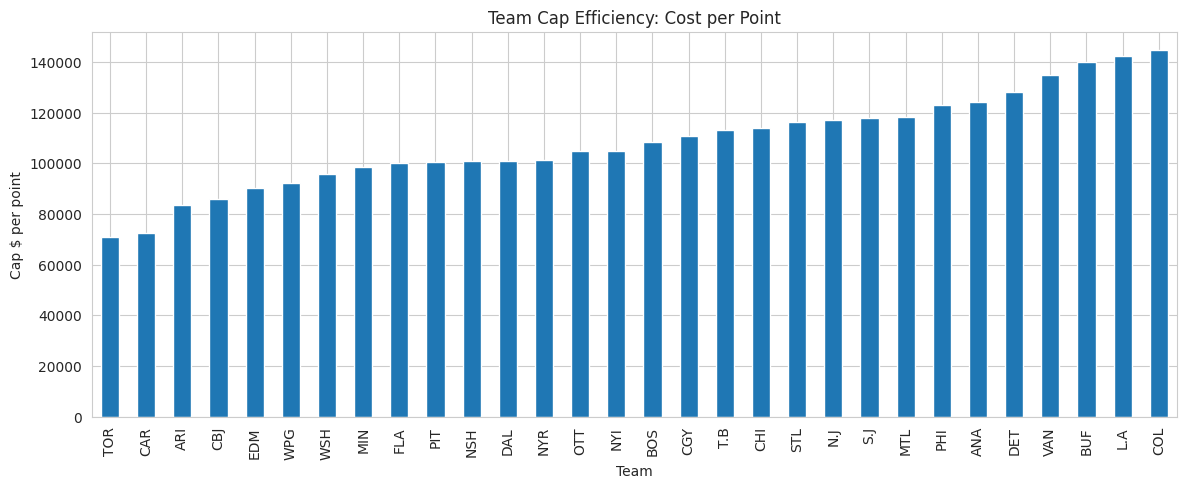

In [ ]:
# Team-level efficiency: total cap spend vs total points
team_eff = df.groupby("Team").agg(
    total_cap=("Salary", "sum"),
    total_points=("P", "sum")
)
team_eff["cost_per_point"] = team_eff["total_cap"] / team_eff["total_points"]
team_eff.sort_values("cost_per_point").plot(kind="bar", y="cost_per_point", figsize=(14,5), legend=False)
plt.ylabel("Cap $ per point")
plt.title("Team Cap Efficiency: Cost per Point")
plt.show()

## 4. Predictive model: contract value from performance

Train a regression model to predict `Salary` (or `AAV`) from performance + bio features.
This lets you flag players whose *actual* cap hit is far from what the model expects —
that gap is your "most underpaid / overpaid" leaderboard.

In [ ]:
features = ["Age", "GP", "G", "A", "P", "PIM"] # Adjusted to available columns after 'Age' creation
target = "Salary"

model_df = df[features + [target, "Team"]].dropna()



X = model_df.drop(columns=[target, "Team"]) # 'Team' is an identifier, not a feature for prediction, so it's dropped from X
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=350, random_state=42)
rf.fit(X_train, y_train)

preds = rf.predict(X_test)
print("R2:", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))

R2: 0.42204457186079847
MAE: 1198811.4659863946


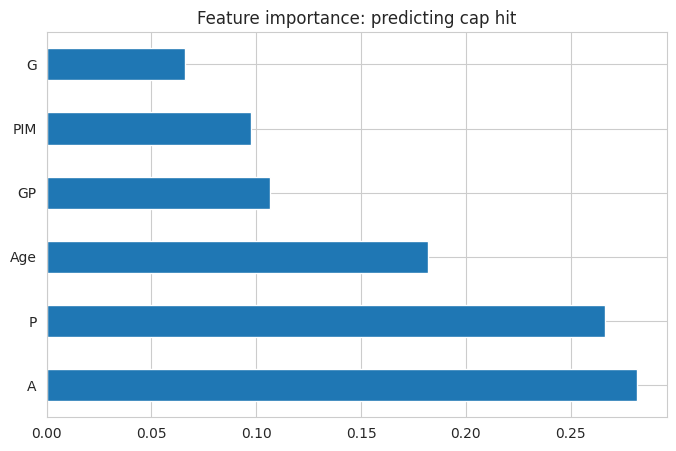

In [ ]:
# Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind="barh", figsize=(8,5))
plt.title("Feature importance: predicting cap hit")
plt.show()


## 5. Underpaid / overpaid leaderboard

In [ ]:
model_df["predicted_cap_hit"] = rf.predict(X)
model_df["residual"] = model_df["Salary"] - model_df["predicted_cap_hit"]
# Negative residual = paid less than model expects given performance -> "underpaid" / good value
# Positive residual = paid more than model expects -> "overpaid"

print("Most underpaid (best value):")
print(model_df.sort_values("residual").head(10)[["Team", "Salary", "predicted_cap_hit", "residual"]])

print("\nMost overpaid:")
print(model_df.sort_values("residual", ascending=False).head(10)[["Team", "Salary", "predicted_cap_hit", "residual"]])

Most underpaid (best value):
    Team     Salary  predicted_cap_hit      residual
559  NSH   640000.0       4.548086e+06 -3.908086e+06
331  OTT  3800000.0       7.538229e+06 -3.738229e+06
93   CGY  3575000.0       6.681443e+06 -3.106443e+06
849  CBJ   650000.0       3.741621e+06 -3.091621e+06
830  DAL  1000000.0       4.046000e+06 -3.046000e+06
114  TOR   925000.0       3.891379e+06 -2.966379e+06
233  WSH   832500.0       3.611907e+06 -2.779407e+06
393  VAN   832500.0       3.583686e+06 -2.751186e+06
554  S.J   625000.0       3.220900e+06 -2.595900e+06
36   NSH  4250000.0       6.758786e+06 -2.508786e+06

Most overpaid:
    Team      Salary  predicted_cap_hit      residual
813  EDM   6000000.0       1.505836e+06  4.494164e+06
671  CHI   9000000.0       4.921103e+06  4.078897e+06
198  BOS   8000000.0       4.217921e+06  3.782079e+06
820  NYR   6000000.0       2.229940e+06  3.770060e+06
621  NSH   6000000.0       2.465500e+06  3.534500e+06
751  COL   5500000.0       2.051200e+06  3.44880

### 6. Most and Least Cap-Efficient Teams

Based on the 'Cost per Point' metric (total team salary divided by total team points):

**Most Cap-Efficient Teams (Lowest Cost per Point):**

In [ ]:
print(team_eff.sort_values("cost_per_point").head(5).round(0))

       total_cap  total_points  cost_per_point
Team                                          
TOR   50600000.0           712         71067.0
CAR   39110000.0           540         72426.0
ARI   35401134.0           424         83493.0
CBJ   54992500.0           640         85926.0
EDM   57415000.0           636         90275.0



**Least Cap-Efficient Teams (Highest Cost per Point):**

In [ ]:
print(team_eff.sort_values("cost_per_point", ascending=False).head(5).round(0))

       total_cap  total_points  cost_per_point
Team                                          
COL   54100000.0           374        144652.0
L.A   76797500.0           540        142218.0
BUF   73275000.0           524        139838.0
VAN   66534500.0           494        134685.0
DET   60990000.0           476        128130.0


### 7. NHL Salary Cap Efficiency - Conclusions

**Team Efficiency:** The three most cap-efficient teams were the Toronto Maple Leafs (\$71K/point), Carolina Hurricanes (\$72K/point), and Arizona Coyotes (\$83K/point, now the Utah Mammoth), despite finishing the season ranked 14th, 21st, and 28th in the overall standings, respectively. The three least cap-efficient teams were the Colorado Avalanche (\$144K/point), LA Kings (\$142K/point), and Buffalo Sabres (\$139K/point), ranked 30th, 22nd, and 26th.

At first glance, this suggests no real link between cap efficiency and on-ice success, only one of the three most efficient teams actually made the playoffs that year. But the pattern holds up better looking at the full picture: 11 of the 16 playoff teams that season ranked in the "Cap Efficiency Playoffs" (top 16) of cap efficiency league-wide. In other words, while the very top of the efficiency leaderboard doesn't predict playoff success on its own, teams in the top half of cap efficiency were considerably more likely to make the playoffs than not.

**Model Performance:** The Random Forest model achieved an R² of 0.42 and a MAE of \$1,198,811 when predicting player cap hit from performance stats. In practical terms, the model explains about 42% of the variation in salary based on on-ice performance alone, meaning a substantial portion of contract value (the remaining ~58%) is driven by factors not captured here, like reputation, term length/contract timing, leadership, and team-specific cap situations at signing. The average prediction is off by about \$1.2M, which is a meaningful margin relative to typical NHL cap hits, so this model is better suited to flagging directional under/overpayment (the leaderboard) than to predicting an exact dollar figure for any one player.

**Other Limitations:** This dataset only includes basic box-score stats (goals, assists, points, +/-, PIM), it's missing modern possession/advanced metrics (Corsi, expected goals, zone-start rates) that often explain a meaningful chunk of a player's actual value, especially for two-way defensive specialists who don't show up well in raw point totals. The model is also trained on a single season (2016-17) rather than multi-year trends, so it can't account for things like a player coming off a career year (inflating perceived value) or signing during a different cap environment contract values assigned in one season reflects that season's market, not necessarily what the same performance would be worth today.

**Roster Coverage Gap (Confirmed):** This dataset does not capture every skater who played for each team that season. Colorado, for example, shows only 19 distinct players in the data despite actually using 37 skaters that season  roughly half their real roster is missing. A team-by-team check (`df.groupby("Team")["Player"].nunique()`) showed this isn't isolated to one team; most teams fall well short of the ~25-35 skaters a club typically dresses across a season due to injuries and call-ups.

**Takeaway:** Team-level point totals and cost-per-point figures in this notebook reflect only the subset of skaters captured in this dataset, not full official team totals. Teams with heavy roster churn (frequent call-ups, injuries) are likely undercounted more than teams with stable lineups  so cross-team efficiency comparisons should be read as directional, not authoritative. This is a limitation of the source data, not a bug in the cleaning pipeline above (duplicate-row and trade-handling checks both came back clean).

**Total cap dollars are also affected (~25% gap vs. expectations).** Estimated missing cap-hit per team ranges roughly \$20M-\$35M, assuming missing players earn the dataset's average salary this is likely an overestimate, since the missing players are probably disproportionately cheaper entry-level/call-up contracts rather than average earners (entry-level deals run ~\$700K-\$925K, well below the league-wide average pulled up by max-cap stars). Treat this as a rough upper bound on the gap, not a precise correction.


### 8. Team rankings

Best to worst cap-effciency list
(standings rank/30) Note:NJ and ARI tied in the standings in points;
                                             *= team ranked 1-16, generally a playoff team
```
TOR (14) *
CAR (21)
ARI (27)
CBJ (4) *
EDM (7) *
WPG (20)
WSH (1) *
MIN (5) *
FLA (23)
PIT (2) *
NSH (15) *
DAL (24)
NYR (9) *
OTT (12) *
NYI (16) *
BOS (13) *
CGY (17)
TB  (18)
CHI (3) *
STL (11) *
NJ  (27)
SJ  (10) *
MTL (8) *
PHI (19)
ANA (6) *
DET (25)
VAN (29)
BUF (26)
LA  (22)
COL (30)
```